In [100]:
# Célula 1: Versão corrigida do EnemExam
import fitz
import re
import os
import pandas as pd
from IPython.display import display, HTML


class EnemExamCorrigido():
    """
    Extrator de questões do ENEM corrigido.
    - Mantém a lógica original de classificação por áreas
    - Corrige bugs (primeira/última questão)
    - Adiciona correção de encoding
    """
    
    def __init__(self):
        self.text = ""
        self.questions = []
        self.questions_topic = []
        self.questions_start = []
        
        self._topics = [
            'matemática e suas tecnologias',
            'linguagens, códigos',
            'ciências humanas',
            'ciências da natureza',
        ]
    
    def read_questions(self, filename):
        """Método principal de extração."""
        print(f"📄 Processando: {filename}")
        self.text = self._convert_from_file(filename)
        self._find_topics()
        self._find_questions()
        print(f"✅ {len(self.questions)} questões extraídas")
        
    def _convert_from_file(self, filename):
        """Converte PDF para texto com correção de encoding."""
        try:
            doc = fitz.open(filename)
        except Exception as e:
            print(f"❌ Erro ao abrir {filename}: {e}")
            return ""
        
        text = ""
        for page in doc:
            text += page.get_text() + "\n\n\n"
        
        doc.close()
        
        # Corrigir encoding quebrado
        text = self._corrigir_encoding(text)
        
        print(f"   Texto extraído: {len(text):,} caracteres")
        return text

    def _corrigir_encoding(self, texto):
        """Corrige caracteres com encoding quebrado."""
        substituicoes = {
            'Ã§': 'ç', 'Ã£': 'ã', 'Ã¡': 'á', 'Ã©': 'é',
            'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú', 'Ã¢': 'â',
            'Ãª': 'ê', 'Ã´': 'ô', 'Ã ': 'à', 'Ãμ': 'õ',
            'Ã‰': 'É', 'Ã€': 'À', 'Ãš': 'Ú', 'Ã”': 'Ô',
            'Ãœ': 'Ü', 'Ã¨': 'è', 'Ã¯': 'ï',
            'Å’': 'ô', 'Å“': 'ö', 'Å¡': 'ù', 'Å½': 'ú',
            'â€œ': '"', 'â€': '"', 'â€¢': '•', 'â€"': '–',
            'Â': '', 'â': '',
            '': '•', '': '',
            '': '(', '': ')', '': '',
            '': '', '': '', '': '', '': '',
            '¿': '', 'À': '',
            'U$': 'R$',
        }
        
        for errado, certo in substituicoes.items():
            texto = texto.replace(errado, certo)
        
        return texto
    
    def _find_topics(self):
        """Encontra as áreas de conhecimento no texto."""
        topic_poss = [self.text.lower().rfind(topic) for topic in self._topics]
        
        self._topics_loc = [
            (topic, topic_pos) 
            for topic, topic_pos in zip(self._topics, topic_poss) 
            if topic_pos > 0
        ]
        self._topics_loc.sort(key=lambda t: t[1])
        
        print(f"   Áreas encontradas: {len(self._topics_loc)}")
        for topic, pos in self._topics_loc:
            print(f"     • {topic.title()}: posição {pos:,}")
    
    def _find_questions(self):
        """Encontra as questões usando o padrão 'questão NN'."""
        matchs = []
        for match in re.finditer('\n(questão) [0-9]+', self.text.lower()):
            matchs.append(match.start())
        
        print(f"   Marcadores encontrados: {len(matchs)}")
        
        self.questions = []
        self.questions_topic = []
        self.questions_start = []
        
        for i in range(len(matchs)):
            inicio = matchs[i]
            
            if i < len(matchs) - 1:
                fim = matchs[i + 1]
            else:
                fim = len(self.text)
            
            questao = self.text[inicio:fim].strip()
            topico = self._define_question_topic(inicio)
            
            self.questions.append(questao)
            self.questions_topic.append(topico)
            self.questions_start.append(inicio)
    
    def _define_question_topic(self, start):
        """Determina a área da questão baseado na posição."""
        question_topic = "UNDEFINED"
        
        for topic, topic_start in self._topics_loc:
            if start > topic_start:
                question_topic = topic
        
        return question_topic
    
    def get_dataframe(self):
        """Retorna DataFrame com resumo das questões."""
        dados = []
        for i, (questao, topico) in enumerate(
            zip(self.questions, self.questions_topic), 1
        ):
            match = re.search(r'questão\s+(\d+)', questao.lower())
            num = int(match.group(1)) if match else 0
            
            dados.append({
                'Índice': i,
                'Questão Nº': num,
                'Área': topico.split(',')[0].title(),
                'Prévia (100 carac.)': questao[:100].replace('\n', ' ') + '...',
                'Tamanho': len(questao)
            })
        
        return pd.DataFrame(dados)
    
    def get_questions_by_topic(self, area):
        """Filtra questões por área."""
        area = area.lower()
        return [
            q for q, t in zip(self.questions, self.questions_topic)
            if area in t.lower()
        ]
    
    def save_questions(self, pasta_base="questoes_enem"):
        """Salva questões em arquivos .txt organizados por área."""
        from collections import Counter
        areas_count = Counter(self.questions_topic)
        
        print(f"\n💾 Salvando questões em '{pasta_base}/'")
        print("=" * 50)
        
        for area in areas_count:
            area_simplificada = area.split(',')[0].strip().replace(' ', '_')
            subpasta = os.path.join(pasta_base, area_simplificada)
            os.makedirs(subpasta, exist_ok=True)
            
            questoes_area = [
                (i, q) for i, (q, t) in enumerate(
                    zip(self.questions, self.questions_topic)
                ) if t == area
            ]
            
            for idx, (indice_original, questao) in enumerate(questoes_area, 1):
                match = re.search(r'questão\s+(\d+)', questao.lower())
                num = int(match.group(1)) if match else idx
                
                nome_arquivo = f"questao_{num:02d}.txt"
                caminho = os.path.join(subpasta, nome_arquivo)
                
                with open(caminho, 'w', encoding='utf-8') as f:
                    f.write(questao)
            
            print(f"  ✓ {area.title()}: {len(questoes_area)} questões")
        
        total = sum(areas_count.values())
        print(f"\n  Total: {total} questões salvas")
    
    def mostrar_questao(self, indice):
        """Mostra uma questão específica pelo índice (1-based)."""
        if 1 <= indice <= len(self.questions):
            display(HTML(f"<h3>Questão {indice} - {self.questions_topic[indice-1].title()}</h3>"))
            print(self.questions[indice - 1])
        else:
            print(f"❌ Índice inválido. Escolha entre 1 e {len(self.questions)}")

In [101]:
# Célula: Processar todos os PDFs e gerar JSON
pasta_provas = './provas'
arquivos = set(os.listdir(pasta_provas))
arquivos_pdf = [f for f in arquivos if f.endswith('.pdf')]

extrator = EnemExamCorrigido()
lista_dfs = []

for arquivo in arquivos_pdf:
    caminho = os.path.join(pasta_provas, arquivo)
    extrator.read_questions(caminho)
    
    # Extrair ano do nome do arquivo
    ano = re.search(r'(\d{4})', arquivo).group(1)
    
    # Extrair número da questão e remover do enunciado
    numeros = []
    enunciados_limpos = []
    
    for enunciado in extrator.questions:
        match = re.search(r'questão\s+(\d+)', enunciado, re.IGNORECASE)
        numero = int(match.group(1)) if match else 0
        enunciado_limpo = re.sub(r'questão\s+\d+\s*[-:.]?\s*', '', enunciado, count=1, flags=re.IGNORECASE).strip()
        
        numeros.append(numero)
        enunciados_limpos.append(enunciado_limpo)
    
    df = pd.DataFrame({
        'numero': numeros,
        'enunciado': enunciados_limpos,
        'area': extrator.questions_topic,
        'ano': ano
    })
    
    lista_dfs.append(df)

# Juntar tudo e salvar
questoes_df = pd.concat(lista_dfs, ignore_index=True)
questoes_df.to_json('enem_questoes.json', orient='records', force_ascii=False)

print(f"✅ JSON criado: {len(questoes_df)} questões salvas em enem_questoes.json")

📄 Processando: ./provas/prova_2012_dia1.pdf
   Texto extraído: 89,599 caracteres
   Áreas encontradas: 2
     • Ciências Humanas: posição 3,430
     • Ciências Da Natureza: posição 53,128
   Marcadores encontrados: 90
✅ 90 questões extraídas
📄 Processando: ./provas/prova_2013_dia2.pdf
   Texto extraído: 102,984 caracteres
   Áreas encontradas: 2
     • Linguagens, Códigos: posição 14,272
     • Matemática E Suas Tecnologias: posição 74,326
   Marcadores encontrados: 95
✅ 95 questões extraídas
📄 Processando: ./provas/prova_2016_dia2.pdf
   Texto extraído: 103,803 caracteres
   Áreas encontradas: 2
     • Linguagens, Códigos: posição 11,051
     • Matemática E Suas Tecnologias: posição 67,863
   Marcadores encontrados: 95
✅ 95 questões extraídas
📄 Processando: ./provas/prova_2010_dia2.pdf
   Texto extraído: 111,646 caracteres
   Áreas encontradas: 2
     • Linguagens, Códigos: posição 22
     • Matemática E Suas Tecnologias: posição 77,283
   Marcadores encontrados: 95
✅ 95 questões extr

In [102]:
df = pd.read_json('enem_questoes.json')

In [103]:
df

,numero,enunciado,area,ano
0,1,"Charge anônima. BURKE, P. A fabricação do rei....",ciências humanas,2012
1,2,Esclarecimento é a saída do homem de sua \nmen...,ciências humanas,2012
2,3,Texto I\nO que vemos no país é uma espécie de ...,ciências humanas,2012
3,4,Disponível em: http://quadro-a-quadro.blog.br....,ciências humanas,2012
4,5,Torna-se claro que quem descobriu a África no ...,ciências humanas,2012
...,...,...,...,...
2955,176,Em um jogo desenvolvido para uso no computador...,matemática e suas tecnologias,2020
2956,177,A Figura 1 apresenta uma casa e a planta do se...,matemática e suas tecnologias,2020
2957,178,Suponha que uma equipe de corrida de automóvei...,matemática e suas tecnologias,2020
2958,179,Um pé de eucalipto em idade adequada para o co...,matemática e suas tecnologias,2020


In [104]:
# Célula: Diagnóstico de encoding no DataFrame
import re
import nltk
from nltk.corpus import stopwords

try:
    PALAVRAS_COMUNS = set(stopwords.words("portuguese")) | set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    PALAVRAS_COMUNS = set(stopwords.words("portuguese")) | set(stopwords.words("english"))


def taxa_reconhecimento(texto: str) -> float:
    """Proporção de palavras do texto que são palavras comuns reconhecidas."""
    palavras = re.findall(r"[a-zA-ZÀ-ÿ]+", texto.lower())
    if len(palavras) < 10:
        return 1.0
    reconhecidas = sum(1 for p in palavras if p in PALAVRAS_COMUNS)
    return reconhecidas / len(palavras)


# Aplicar diagnóstico em cada enunciado
questoes_df['taxa_reconhecimento'] = questoes_df['enunciado'].apply(taxa_reconhecimento)
questoes_df['suspeita'] = questoes_df['taxa_reconhecimento'] < 0.20

# Relatório por arquivo/ano
print(f"{ano:6s} {'questões':>10s} {'suspeitas':>10s} {'%':>6s}")
print("-" * 45)

for ano in sorted(questoes_df['ano'].unique()):
    df_ano = questoes_df[questoes_df['ano'] == ano]
    total = len(df_ano)
    suspeitas = df_ano['suspeita'].sum()
    pct = 100 * suspeitas / total if total else 0
    marcador = "  <-- revisar" if pct > 10 else ""
    print(f"{ano:6s} {total:>10d} {suspeitas:>10d} {pct:>5.1f}%{marcador}")

print("-" * 45)
total = len(questoes_df)
suspeitas = questoes_df['suspeita'].sum()
print(f"TOTAL  {total:>10d} {suspeitas:>10d} {100*suspeitas/total:>5.1f}%")

# Ver amostra de questões suspeitas
print("\n📝 Amostra de questões suspeitas:")
for _, row in questoes_df[questoes_df['suspeita']].head(3).iterrows():
    print(f"\nAno: {row['ano']} | Área: {row['area']} | Taxa: {row['taxa_reconhecimento']:.2f}")
    print(row['enunciado'][:200])

2020     questões  suspeitas      %
---------------------------------------------
2010          185          1   0.5%
2011          185          1   0.5%
2012          185          0   0.0%
2013          185          0   0.0%
2014          185          0   0.0%
2015          185          1   0.5%
2016          185          1   0.5%
2017          185          7   3.8%
2018          185          4   2.2%
2019          185          0   0.0%
2020          185          0   0.0%
2021          185         12   6.5%
2022          185          4   2.2%
2023          185          1   0.5%
2024          185         35  18.9%  <-- revisar
2025          185          8   4.3%
---------------------------------------------
TOTAL        2960         75   2.5%

📝 Amostra de questões suspeitas:

Ano: 2010 | Área: matemática e suas tecnologias | Taxa: 0.07
Um professor dividiu a lousa da sala de aula em quatro 
partes iguais. Em seguida, preencheu 75% dela com 
FRQFHLWRVHH[SOLFDo}HVFRQIRUPHDJXUDVHJXLQWH


In [105]:
# Ou manter todas com a coluna de alerta
questoes_df.to_json('enem_questoes.json', orient='records', force_ascii=False)

In [106]:
questoes_df['suspeita'] = questoes_df['taxa_reconhecimento'] <= 0.2

questoes_df[questoes_df['suspeita'] == True]

,numero,enunciado,area,ano,taxa_reconhecimento,suspeita
330,136,Um professor dividiu a lousa da sala de aula e...,matemática e suas tecnologias,2010,0.071651,True
403,119,$ XWLOL]DomR GH H[WUDWRV GH RULJHP QDWXUDO WHP...,ciências da natureza,2018,0.186441,True
409,125,$JXUDUHSUHVHQWDXPSULVPDySWLFRFRQVWLWXtGRGHXPP...,ciências da natureza,2018,0.191781,True
410,126,7HQVRDWLYRV VmR FRPSRVWRV RUJkQLFRV TXH SRVVXH...,ciências da natureza,2018,0.194444,True
452,168,"A raiva é uma doença viral e infecciosa, trans...",matemática e suas tecnologias,2018,0.197917,True
...,...,...,...,...,...,...
2410,1,Las lenguas originarias de nuestra nación\ngua...,UNDEFINED,2022,0.165854,True
2458,49,10% - 20% de superfície impermeável\npercolaçã...,ciências humanas,2022,0.140127,True
2474,65,"carinho, paixão, presentes, promessas, reconci...",ciências humanas,2022,0.162921,True
2719,125,Na figura está representado o mosaicismo em fu...,ciências da natureza,2021,0.188679,True


In [108]:
# Remover questões suspeitas (encoding ruim)
questoes_limpas = questoes_df[questoes_df['suspeita'] == False]

# Remover questões com área UNDEFINED
questoes_limpas = questoes_limpas[questoes_limpas['area'] != "UNDEFINED"]

print(f"Original: {len(questoes_df)} questões")
print(f"Após limpeza: {len(questoes_limpas)} questões")
print(f"Removidas: {len(questoes_df) - len(questoes_limpas)} questões")

Original: 2960 questões
Após limpeza: 2605 questões
Removidas: 355 questões


In [107]:
questoes_limpas

,numero,enunciado,area,ano,taxa_reconhecimento,suspeita
0,1,"Charge anônima. BURKE, P. A fabricação do rei....",ciências humanas,2012,0.409091,False
1,2,Esclarecimento é a saída do homem de sua \nmen...,ciências humanas,2012,0.462882,False
2,3,Texto I\nO que vemos no país é uma espécie de ...,ciências humanas,2012,0.435540,False
3,4,Disponível em: http://quadro-a-quadro.blog.br....,ciências humanas,2012,0.374194,False
4,5,Torna-se claro que quem descobriu a África no ...,ciências humanas,2012,0.385621,False
...,...,...,...,...,...,...
2955,176,Em um jogo desenvolvido para uso no computador...,matemática e suas tecnologias,2020,0.344538,False
2956,177,A Figura 1 apresenta uma casa e a planta do se...,matemática e suas tecnologias,2020,0.494118,False
2957,178,Suponha que uma equipe de corrida de automóvei...,matemática e suas tecnologias,2020,0.444444,False
2958,179,Um pé de eucalipto em idade adequada para o co...,matemática e suas tecnologias,2020,0.451220,False


In [109]:
# Diagnóstico nas questões limpas
questoes_limpas['taxa_reconhecimento'] = questoes_limpas['enunciado'].apply(taxa_reconhecimento)

print("📊 Taxa de reconhecimento após limpeza:")
print(f"  Média: {questoes_limpas['taxa_reconhecimento'].mean():.3f}")
print(f"  Mínimo: {questoes_limpas['taxa_reconhecimento'].min():.3f}")
print(f"  Máximo: {questoes_limpas['taxa_reconhecimento'].max():.3f}")

# Ver algumas das 2605 que ficaram
print("\n📝 Amostra das questões mantidas:")
for _, row in questoes_limpas.sample(3).iterrows():
    print(f"\nAno: {row['ano']} | Área: {row['area']} | Taxa: {row['taxa_reconhecimento']:.3f}")
    print(row['enunciado'][:200])
    print("-" * 50)

📊 Taxa de reconhecimento após limpeza:
  Média: 0.388
  Mínimo: 0.202
  Máximo: 0.590

📝 Amostra das questões mantidas:

Ano: 2012 | Área: ciências humanas | Taxa: 0.409
Charge anônima. BURKE, P. A fabricação do rei. Rio de Janeiro: Zahar, 1994.
Na França, o rei Luís XIV teve sua imagem fabricada por 
um conjunto de estratégias que visavam sedimentar uma 
determinada 
--------------------------------------------------

Ano: 2018 | Área: linguagens, códigos | Taxa: 0.244
Qué es la X Solidaria?
La X Solidaria es una equis que ayuda a las personas 
más vulnerables. Podrás marcarla cuando hagas la 
declaración de la renta. Es la casilla que se denomina 
“Fines Sociales”.
--------------------------------------------------

Ano: 2021 | Área: matemática e suas tecnologias | Taxa: 0.292
Peças metálicas de aeronaves abandonadas em 
aeroportos serão recicladas. Uma dessas peças é 
maciça e tem o formato cilíndrico, com a medida do raio 
da base igual a 4 cm e a da altura igual a 50 cm.
---------

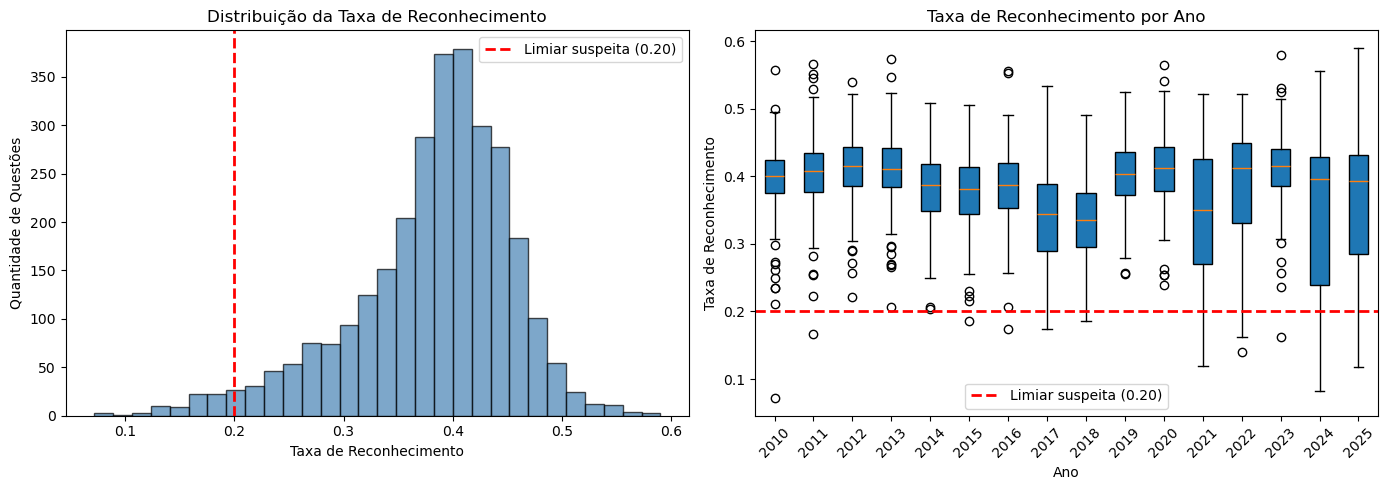

In [110]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição da taxa de reconhecimento
axes[0].hist(questoes_df['taxa_reconhecimento'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.20, color='red', linestyle='--', linewidth=2, label='Limiar suspeita (0.20)')
axes[0].set_xlabel('Taxa de Reconhecimento')
axes[0].set_ylabel('Quantidade de Questões')
axes[0].set_title('Distribuição da Taxa de Reconhecimento')
axes[0].legend()

# Gráfico 2: Boxplot por ano
taxas_por_ano = [questoes_df[questoes_df['ano'] == ano]['taxa_reconhecimento'].values 
                 for ano in sorted(questoes_df['ano'].unique())]
anos = sorted(questoes_df['ano'].unique())

bp = axes[1].boxplot(taxas_por_ano, patch_artist=True)
axes[1].axhline(y=0.20, color='red', linestyle='--', linewidth=2, label='Limiar suspeita (0.20)')
axes[1].set_xticklabels(anos, rotation=45)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Taxa de Reconhecimento')
axes[1].set_title('Taxa de Reconhecimento por Ano')
axes[1].legend()

plt.tight_layout()
plt.show()

In [114]:
questoes_limpas[questoes_limpas["suspeita"] == True]

,numero,enunciado,area,ano,taxa_reconhecimento,suspeita


In [115]:
questoes_limpas.to_json('questoes_limpas.json', orient='records', force_ascii=False)
print(f"✅ Salvo: questoes_limpas.json ({len(questoes_limpas)} questões)")

✅ Salvo: questoes_limpas.json (2605 questões)


In [119]:
# Ver uma questão completa para identificar o padrão das alternativas
print(questoes_limpas.iloc[0]['enunciado'])
print("\n" + "="*50 + "\n")
print(questoes_limpas.iloc[1]['enunciado'])
print("\n" + "="*50 + "\n")
print(questoes_limpas.iloc[2000]['enunciado'])
print("\n" + "="*50 + "\n")

Charge anônima. BURKE, P. A fabricação do rei. Rio de Janeiro: Zahar, 1994.
Na França, o rei Luís XIV teve sua imagem fabricada por 
um conjunto de estratégias que visavam sedimentar uma 
determinada noção de soberania. Neste sentido, a charge 
apresentada demonstra
A	 a humanidade do rei, pois retrata um homem comum, 
sem os adornos próprios à vestimenta real.
B	 a unidade entre o público e o privado, pois a figura do 
rei com a vestimenta real representa o público e sem 
a vestimenta real, o privado.
C	 o vínculo entre monarquia e povo, pois leva 
ao conhecimento do público a figura de um rei 
despretensioso e distante do poder político.
D	 o gosto estético refinado do rei, pois evidencia a 
elegncia dos trajes reais em relação aos de outros 
membros da corte.
E	 a importncia da vestimenta para a constituição 
simbólica do rei, pois o corpo político adornado 
esconde os defeitos do corpo pessoal.


Esclarecimento é a saída do homem de sua 
menoridade, da qual ele próprio é culpado. A

In [121]:
import re

def separar_enunciado_alternativas(texto):
    """Separa o enunciado das alternativas em vários formatos."""
    
    # Limpar sujeira no final (páginas, códigos, etc.)
    texto = re.sub(r'\n\*[A-Z0-9]+\*\n', '', texto)
    texto = re.sub(r'\n[A-Z]{2,3}\s*[-–]\s*\d[°º]\s*dia.*', '', texto)
    texto = re.sub(r'\n\d+\n', '', texto)
    
    # Padrões de alternativas
    padroes = [
        r'\n(A|a)\t',
        r'\n(A|a)\s{2,}',
        r'\n(A|a)\s+(A|a)\s',
    ]
    
    inicio_alternativas = None
    for padrao in padroes:
        match = re.search(padrao, texto)
        if match:
            inicio_alternativas = match.start()
            break
    
    if inicio_alternativas:
        enunciado = texto[:inicio_alternativas].strip()
        alternativas_bloco = texto[inicio_alternativas:].strip()
        
        # Remover duplicação (A A → A)
        alternativas_bloco = re.sub(r'(?<=\n)([A-E])\s+\1\s', r'\1 ', alternativas_bloco)
        
        # Separar alternativas
        alternativas = re.split(r'\n(?=[A-E]\s)', alternativas_bloco)
        alternativas = [re.sub(r'^[A-E]\s+', '', alt).strip() for alt in alternativas if alt.strip()]
        
        return enunciado, alternativas
    else:
        return texto, []

In [122]:
import json

def construir_json_questao(row):
    """Constrói o JSON estruturado para uma questão."""
    
    # Extrair número da questão
    match = re.search(r'questão\s+(\d+)', row['enunciado'], re.IGNORECASE)
    numero = int(match.group(1)) if match else 0
    
    # Separar enunciado e alternativas (usando a função que já temos)
    enunciado, alternativas = separar_enunciado_alternativas(row['enunciado'])
    
    # Mapear área para discipline
    disciplina = row['area'].split(',')[0].strip() if row['area'] else None
    
    # Construir alternativas no formato desejado
    alts_formatadas = []
    letras = ['A', 'B', 'C', 'D', 'E']
    
    for i, alt in enumerate(alternativas[:5]):  # máx 5 alternativas
        if i < len(letras):
            alts_formatadas.append({
                "letter": letras[i],
                "text": alt,
                "file": None,
                "isCorrect": None  # null por enquanto
            })
    
    # Se tem menos de 5, preencher com None
    while len(alts_formatadas) < 5:
        alts_formatadas.append(None)
    
    # Extrair a introdução das alternativas (texto logo antes do "A")
    intro_alternativas = ""
    if alternativas:
        padrao = r'(?:demonstra|representa|correto|correta|expressa|afirmar|considerações|resposta|alternativa|procedimento|medida|ação|solução|problema|relação|é|são|ser|está|estão)[^.]*?$'
        match_intro = re.search(padrao, enunciado, re.IGNORECASE)
        if match_intro:
            intro_alternativas = match_intro.group(0).strip()
    
    questao_json = {
        "title": f"Questão {numero} - ENEM {row['ano']}",
        "index": numero,
        "year": int(row['ano']),
        "language": "português",
        "discipline": disciplina,
        "context": enunciado,
        "files": [],
        "correctAlternative": None,  # null até ter gabarito
        "alternativesIntroduction": intro_alternativas,
        "alternatives": alts_formatadas
    }
    
    return questao_json

# Aplicar em todas as questões
questoes_json = questoes_limpas.apply(construir_json_questao, axis=1).tolist()

# Salvar
with open('enem_questoes_estruturado.json', 'w', encoding='utf-8') as f:
    json.dump(questoes_json, f, ensure_ascii=False, indent=2)

print(f"✅ {len(questoes_json)} questões salvas em enem_questoes_estruturado.json")

# Ver primeira
print("\nExemplo:")
print(json.dumps(questoes_json[0], ensure_ascii=False, indent=2)[:500])

✅ 2605 questões salvas em enem_questoes_estruturado.json

Exemplo:
{
  "title": "Questão 0 - ENEM 2012",
  "index": 0,
  "year": 2012,
  "language": "português",
  "discipline": "ciências humanas",
  "context": "Charge anônima. BURKE, P. A fabricação do rei. Rio de Janeiro: Zahar, 1994.\nNa França, o rei Luís XIV teve sua imagem fabricada por \num conjunto de estratégias que visavam sedimentar uma \ndeterminada noção de soberania. Neste sentido, a charge \napresentada demonstra",
  "files": [],
  "correctAlternative": null,
  "alternativesIntroduction": "demons


In [123]:
import json
import requests
import os

# 1. Baixar todos os JSONs do repositório (2009-2023)
print("📥 Baixando JSONs do repositório...")
anos_repo = range(2009, 2024)
questoes_existentes = []

for ano in anos_repo:
    url = f"https://raw.githubusercontent.com/yunger7/enem-api/main/data/enem_{ano}.json"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        questoes_ano = response.json()
        questoes_existentes.extend(questoes_ano)
        print(f"  ✓ {ano}: {len(questoes_ano)} questões")
    except:
        print(f"  ✗ {ano}: não encontrado")

print(f"\nTotal do repositório: {len(questoes_existentes)} questões")

# 2. Pegar questões novas (2024+) do seu DataFrame
questoes_novas = questoes_limpas[questoes_limpas['ano'].astype(int) >= 2024]

if len(questoes_novas) > 0:
    print(f"\n📝 Convertendo {len(questoes_novas)} questões novas...")
    questoes_novas_json = questoes_novas.apply(construir_json_questao, axis=1).tolist()
    print(f"  ✓ {len(questoes_novas_json)} convertidas")
else:
    questoes_novas_json = []
    print("\n📝 Nenhuma questão nova para adicionar")

# 3. Juntar tudo
todas = questoes_existentes + questoes_novas_json

# 4. Salvar
with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"\n✅ enem_completo.json salvo com {len(todas)} questões")

📥 Baixando JSONs do repositório...
  ✗ 2009: não encontrado
  ✗ 2010: não encontrado
  ✗ 2011: não encontrado
  ✗ 2012: não encontrado
  ✗ 2013: não encontrado
  ✗ 2014: não encontrado
  ✗ 2015: não encontrado
  ✗ 2016: não encontrado
  ✗ 2017: não encontrado
  ✗ 2018: não encontrado
  ✗ 2019: não encontrado
  ✗ 2020: não encontrado
  ✗ 2021: não encontrado
  ✗ 2022: não encontrado
  ✗ 2023: não encontrado

Total do repositório: 0 questões

📝 Convertendo 159 questões novas...
  ✓ 159 convertidas

✅ enem_completo.json salvo com 159 questões


In [124]:
import json

def extrair_numero(enunciado):
    match = re.search(r'questão\s+(\d+)', enunciado, re.IGNORECASE)
    return int(match.group(1)) if match else 0

def mapear_disciplina(area):
    mapeamento = {
        'linguagens, códigos': 'linguagens-codigos',
        'ciências humanas': 'ciencias-humanas',
        'ciências da natureza': 'ciencias-natureza',
        'matemática e suas tecnologias': 'matematica'
    }
    for chave, valor in mapeamento.items():
        if chave in area.lower():
            return valor
    return None

def construir_json_questao(row):
    numero = extrair_numero(row['enunciado'])
    enunciado, alternativas = separar_enunciado_alternativas(row['enunciado'])
    disciplina = mapear_disciplina(row['area'])
    
    # Alternativas no formato do repositório
    alts_formatadas = []
    letras = ['A', 'B', 'C', 'D', 'E']
    
    for i, alt in enumerate(alternativas[:5]):
        if i < len(letras):
            alts_formatadas.append({
                "letter": letras[i],
                "text": alt,
                "file": None,
                "isCorrect": False  # False por padrão, ajustar com gabarito depois
            })
    
    # Preencher até 5 alternativas
    while len(alts_formatadas) < 5:
        alts_formatadas.append(None)
    
    # Introdução das alternativas (última frase antes das opções)
    intro = ""
    if alternativas:
        linhas_enunciado = enunciado.split('\n')
        intro = linhas_enunciado[-1].strip() if linhas_enunciado else ""
    
    return {
        "title": f"Questão {numero} - ENEM {row['ano']}",
        "index": numero,
        "year": int(row['ano']),
        "language": None,
        "discipline": disciplina,
        "context": enunciado,
        "files": [],
        "correctAlternative": None,  # Preencher quando tiver gabarito
        "alternativesIntroduction": intro,
        "alternatives": alts_formatadas
    }

# Aplicar nas questões novas (2024+)
questoes_novas = questoes_limpas[questoes_limpas['ano'].astype(int) >= 2024]
questoes_novas_json = questoes_novas.apply(construir_json_questao, axis=1).tolist()

# Juntar com as existentes e salvar
todas = questoes_existentes + questoes_novas_json

with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"✅ {len(todas)} questões salvas em enem_completo.json")

✅ 159 questões salvas em enem_completo.json


In [125]:
import json
import requests

# Baixar JSONL
url = "https://raw.githubusercontent.com/piresramon/gpt-4-enem/main/data/enem/2024.jsonl"
response = requests.get(url)
linhas = response.text.strip().split('\n')

# Converter para o formato do repositório
questoes_2024 = []

for linha in linhas:
    dados = json.loads(linha)
    
    # Extrair número da questão (ex: "questao_01" → 1)
    numero = int(dados['id'].replace('questao_', ''))
    
    # Mapear disciplina (não tem no JSON, definir como None)
    disciplina = None
    
    # Construir alternativas no formato padrão
    letras = ['A', 'B', 'C', 'D', 'E']
    alternatives = []
    for i, texto in enumerate(dados['alternatives'][:5]):
        alternatives.append({
            "letter": letras[i],
            "text": texto,
            "file": None,
            "isCorrect": letras[i] == dados['label']
        })
    
    # Preencher até 5
    while len(alternatives) < 5:
        alternatives.append(None)
    
    # Separar enunciado da introdução das alternativas
    # (o texto da questão inclui a pergunta final, não separamos)
    questao_json = {
        "title": f"Questão {numero} - ENEM 2024",
        "index": numero,
        "year": 2024,
        "language": None,
        "discipline": disciplina,
        "context": dados['question'],
        "files": [],
        "correctAlternative": dados['label'],
        "alternativesIntroduction": None,
        "alternatives": alternatives
    }
    
    questoes_2024.append(questao_json)

print(f"✅ {len(questoes_2024)} questões convertidas")

# Juntar com as existentes e salvar
todas = questoes_existentes + questoes_2024

with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"✅ enem_completo.json atualizado com {len(todas)} questões")

✅ 180 questões convertidas
✅ enem_completo.json atualizado com 180 questões


In [ ]:
tenho agora dois json